<a href="https://colab.research.google.com/github/ishwarraja/SOAI/blob/main/S5/EVA4_Session_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.01MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             144
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
           Dropout-4           [-1, 16, 28, 28]               0
            Conv2d-5           [-1, 16, 28, 28]           2,304
       BatchNorm2d-6           [-1, 16, 28, 28]              32
              ReLU-7           [-1, 16, 28, 28]               0
           Dropout-8           [-1, 16, 28, 28]               0
            Conv2d-9            [-1, 8, 28, 28]             128
        MaxPool2d-10            [-1, 8, 14, 14]               0
           Conv2d-11           [-1, 16, 14, 14]           1,152
      BatchNorm2d-12           [-1, 16, 14, 14]              32
             ReLU-13           [-1, 16, 14, 14]               0
          Dropout-14           [-1, 16,

100%|██████████| 938/938 [00:16<00:00, 55.29it/s]


Epoch: 1/15.. Time: 16.97s.. Training Loss: 0.194.. Training Accu: 94.105.. Val Loss: 0.073.. Val Accu: 97.810


100%|██████████| 938/938 [00:15<00:00, 59.94it/s]


...

Epoch: 13/15.. Time: 15.64s.. Training Loss: 0.015.. Training Accu: 99.532.. Val Loss: 0.019.. Val Accu: 99.310


100%|██████████| 938/938 [00:15<00:00, 60.20it/s]


Epoch: 14/15.. Time: 15.58s.. Training Loss: 0.015.. Training Accu: 99.517.. Val Loss: 0.018.. Val Accu: 99.340


100%|██████████| 938/938 [00:16<00:00, 55.95it/s]


Epoch: 15/15.. Time: 16.77s.. Training Loss: 0.014.. Training Accu: 99.558.. Val Loss: 0.018.. Val Accu: 99.380


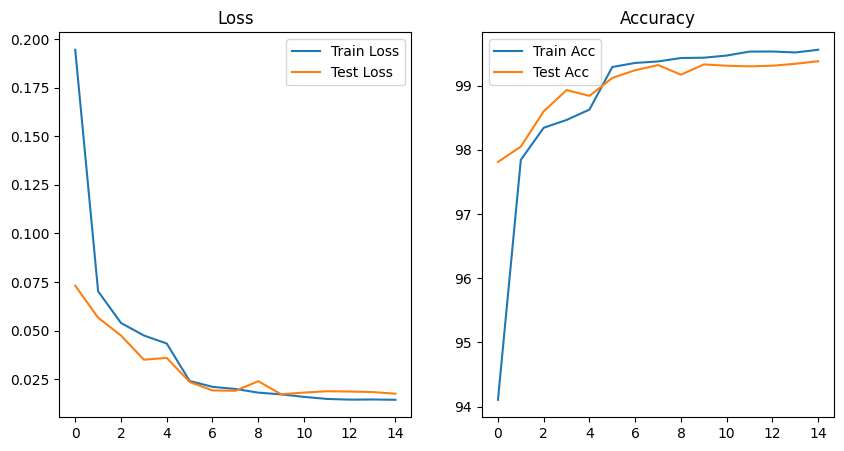

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchsummary import summary
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

# --------------------
# Model
# --------------------
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(0.05)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(0.05)
        )
        # Transition 1
        self.trans1 = nn.Sequential(
            nn.Conv2d(16, 8, 1, bias=False),
            nn.MaxPool2d(2, 2)
        )
        # Block 2
        self.conv3 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(0.05)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(0.05)
        )
        # Transition 2
        self.trans2 = nn.Sequential(
            nn.Conv2d(16, 16, 1, bias=False),
            nn.MaxPool2d(2, 2)
        )
        # Block 3
        self.conv5 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.05)
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.05)
        )
        # Output
        self.conv7 = nn.Conv2d(32, 10, 1, bias=False)
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.trans1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.trans2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.gap(x)
        x = x.view(-1, 10)
        return F.log_softmax(x, dim=1)

# --------------------
# Training Utilities
# --------------------
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    correct, train_loss = 0, 0
    start = time.time()
    for data, target in tqdm(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        train_loss += loss.item() * data.size(0)
        loss.backward()
        optimizer.step()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    end = time.time()
    train_loss /= len(train_loader.dataset)
    acc = 100. * correct / len(train_loader.dataset)
    return train_loss, acc, end-start

def test(model, device, test_loader):
    model.eval()
    correct, test_loss = 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    return test_loss, acc

# --------------------
# Setup
# --------------------
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

batch_size = 64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True if use_cuda else False)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, transform=transform),
    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True if use_cuda else False)

model = Net().to(device)
summary(model, input_size=(1, 28, 28))
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# --------------------
# Training Loop
# --------------------
num_epochs = 15
train_losses, test_losses, train_accs, test_accs = [], [], [], []

for epoch in range(1, num_epochs+1):
    train_loss, train_acc, t = train(model, device, train_loader, optimizer, epoch)
    val_loss, val_acc = test(model, device, test_loader)
    scheduler.step()
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    train_accs.append(train_acc)
    test_accs.append(val_acc)
    print(f"Epoch: {epoch}/{num_epochs}.. Time: {t:.2f}s.. "
          f"Training Loss: {train_loss:.3f}.. Training Accu: {train_acc:.3f}.. "
          f"Val Loss: {val_loss:.3f}.. Val Accu: {val_acc:.3f}")

# --------------------
# Plotting
# --------------------
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.legend()
plt.title("Accuracy")
plt.show()
